In [3]:
# 讀入習慣的資料科學套件
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [52]:
#讀入資料，這邊要注意檔案的儲存路徑！
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') 
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
# 查看數據的變數、總數、缺失數據、變數measurement(維度)
def data_overview():
    print("Rows :  " , df.shape[0])
    print("Columns:  " , df.shape[1] )
    print('Missing Value number : ' , df.isnull().sum().values.sum()) #isnull.sum()會對每條series做sum up ，所以我們還要取出value做一次sum up .
    print('\nUnique values' , df.nunique())
data_overview()

Rows :   7043
Columns:   21
Missing Value number :  0

Unique values customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


##資料操作

In [54]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [56]:
df['Churn'].value_counts(normalize=True).round(3) #normalize=True 會將數據轉換成百分比，

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

<Axes: xlabel='tenure', ylabel='Count'>

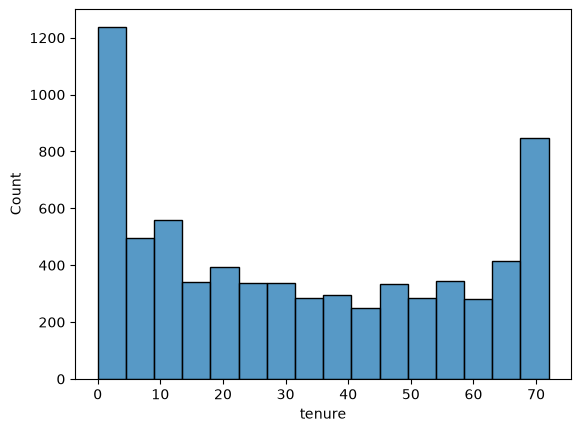

In [57]:
# 作圖發現有極端值的嫌疑
sns.histplot(df.tenure)

In [58]:
# 替代掉空白值當作null
df['TotalCharges'] = df.TotalCharges.replace(' ' , np.nan)
print('缺失數據變為：')
print(df.TotalCharges.isnull().sum())
# 查看都是哪些類型的數據缺失
df[df.TotalCharges.isnull()]
#查看原始數據，我們知道二分數據為Yes/No，我們想要把他們編碼，這樣方便之後的modeling
df = df.replace({'Yes':1 , 'No' :0})

#再轉換一次型態
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

#轉換二項data-churn的型態，將Yes轉換為1，No轉換為0
#df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#繼續清理數據，將No internet service轉換為No
no_internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                     'TechSupport','StreamingTV','StreamingMovies']
for c in no_internet_cols:
    df[c] = df[c].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

df.head()




缺失數據變為：
11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


##特徵工程

In [59]:
print(df.tenure.describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [60]:
#撰寫一個將tenure轉變為離散變量的函數，轉為離散類別群組
def tenure_to_bins(series):
    labels = [1,2,3,4,5]
    bins = pd.cut(series , bins = 5 , labels = labels)
    return bins
temp_tenure = df.tenure
df['tenure_group'] = tenure_to_bins(temp_tenure)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,1,0,1,0,No,DSL,0,...,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,1
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,0,0,One year,0,Mailed check,56.95,1889.50,0,3
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,1
3,7795-CFOCW,Male,0,0,0,45,0,No,DSL,1,...,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,4
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,1


In [ ]:
# 將兩類數據分開
churn = df[df.Churn == 1] #流失的客戶
not_churn = df[df.Churn == 0] #未流失的客戶

# 將類別變數與連續變數分開
Id_col = ['customerID']
target_col = ['Churn']
cat_cols = df.nunique()[df.nunique() < 6].keys().tolist() #取出Series.index，轉成一個list
cat_cols = [col for col in cat_cols if col not in target_col]
num_cols = [x for x in df.columns if x not in Id_col + target_col + cat_cols]

print(churn)
print(not_churn)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
2     3668-QPYBK    Male              0       0          0       2   
4     9237-HQITU  Female              0       0          0       2   
5     9305-CDSKC  Female              0       0          0       8   
8     7892-POOKP  Female              0       1          0      28   
13    0280-XJGEX    Male              0       0          0      49   
...          ...     ...            ...     ...        ...     ...   
7021  1699-HPSBG    Male              0       0          0      12   
7026  8775-CEBBJ  Female              0       0          0       9   
7032  6894-LFHLY    Male              1       0          0       1   
7034  0639-TSIQW  Female              0       0          0      67   
7041  8361-LTMKD    Male              1       1          0       4   

     PhoneService MultipleLines InternetService OnlineSecurity  ...  \
2               1             0             DSL              1  ...   
4               1

##EDA

In [34]:
# 先導入相關套件
import plotly.offline as py
py.init_notebook_mode(connected=True) #為了能在本地端調用
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.figure_factory as ff

In [65]:
import plotly.express as px

fig = px.pie(
    df, 
    names=df['Churn'].map({0: 'Not Churn', 1: 'Churn'}),
    title="Customer attrition in data",
    color_discrete_sequence=['royalblue', 'lime'],
    hole=0.5
)
fig.update_traces(marker=dict(line=dict(color='white', width=1.3)), rotation=90)
#得到客戶流失比例! 
#通過這個圖，我們可以看到大約有26%的客戶流失，不過通常客戶流失屬於稀有事件。
fig.show()

In [74]:
#匯出到Tableau 分析
# 存入當前目錄下的 data 資料夾
df.to_excel('../data/processed/processed_customer_churn.xlsx', index=False)

目前工作目錄： d:\Sourcecode\Dev\operations-analytics\notebooks
目前目錄檔案： ['customer_churn.ipynb']
